Every large scale analytics project starts with getting the right tools in place. NYC's taxi trip data is distributed in Parquet format a compressed, columnar file type built for handling millions of rows efficiently, far better than CSV at this scale. Before I can touch the data, I need pyarrow, the engine pandas relies on to read Parquet files.

In [17]:
!pip install pyarrow -q

With the environment ready, I bring in the full toolkit for this project: pandas and NumPy for data manipulation, Matplotlib and Seaborn for visual storytelling, SciPy for statistical testing, and Scikit-learn for building a predictive model later on. Loading everything upfront keeps the rest of the notebook clean and focused on analysis rather than setup.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")

This is where the real data enters the picture: one month of NYC Yellow Taxi trips several million individual rides, each with a pickup time, dropoff time, fare, distance, and location codes. Alongside it, I load a zone lookup table that translates those raw location IDs into actual boroughs like Manhattan or Brooklyn, since the trip data alone only speaks in numeric codes.

In [19]:
trips = pd.read_parquet("/content/yellow_tripdata_2024-07.parquet")
zones = pd.read_csv("/content/taxi_zone_lookup.csv")

print("Rows:", len(trips))
trips.head()

Rows: 3076903


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2024-07-01 00:34:56,2024-07-01 00:46:49,1.0,3.20,1.0,N,140,79,1,15.6,3.50,0.5,3.50,0.00,1.0,24.10,2.5,0.00
1,2,2024-06-30 23:48:58,2024-07-01 00:28:04,1.0,19.48,2.0,N,132,113,2,70.0,0.00,0.5,0.00,0.00,1.0,75.75,2.5,1.75
2,2,2024-07-01 00:23:18,2024-07-01 00:29:51,1.0,1.18,1.0,N,237,145,1,8.6,1.00,0.5,2.72,0.00,1.0,16.32,2.5,0.00
3,1,2024-07-01 00:10:33,2024-07-01 00:27:31,0.0,9.10,1.0,N,138,164,1,36.6,10.25,0.5,12.05,0.00,1.0,60.40,2.5,1.75
4,1,2024-07-01 00:07:55,2024-07-01 00:34:34,1.0,17.70,2.0,N,132,263,1,70.0,1.75,0.5,10.00,6.94,1.0,90.19,0.0,1.75


Real world data is never clean. Among millions of trips, there are inevitable errors: fares of zero or negative dollars, trips lasting a few seconds due to meter glitches, and GPS anomalies logging impossible distances. Before I can trust any analysis or model built on this data, I filter these anomalies out this single step is often what separates a rigorous analysis from a misleading one.

In [20]:
trips["trip_duration_min"] = (
    trips["tpep_dropoff_datetime"] - trips["tpep_pickup_datetime"]
).dt.total_seconds() / 60

trips_clean = trips[
    (trips["trip_distance"] > 0) & (trips["trip_distance"] < 100) &
    (trips["fare_amount"] > 0) & (trips["fare_amount"] < 500) &
    (trips["passenger_count"] > 0) &
    (trips["trip_duration_min"] > 1) & (trips["trip_duration_min"] < 180)
].copy()

print("Before:", len(trips)); print("After:", len(trips_clean))

Before: 3076903
After: 2671455


Raw timestamps and ID codes don't tell a story on their own they need to be translated into meaningful signals. Here, I extract the hour and day of each pickup, flag weekend trips, calculate average speed, and map location codes to borough names. These engineered features are what actually let me ask business questions like "when is demand highest?" and "does location affect trip patterns?"

In [21]:
trips_clean["pickup_hour"] = trips_clean["tpep_pickup_datetime"].dt.hour
trips_clean["pickup_dow"] = trips_clean["tpep_pickup_datetime"].dt.day_name().str[:3]
trips_clean["is_weekend"] = trips_clean["tpep_pickup_datetime"].dt.dayofweek.isin([5, 6])
trips_clean["avg_speed_mph"] = trips_clean["trip_distance"] / (trips_clean["trip_duration_min"] / 60)

zone_map = zones.set_index("LocationID")["Borough"]
trips_clean["pickup_borough"] = trips_clean["PULocationID"].map(zone_map)
trips_clean["dropoff_borough"] = trips_clean["DOLocationID"].map(zone_map)

trips_clean.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,trip_duration_min,pickup_hour,pickup_dow,is_weekend,avg_speed_mph,pickup_borough,dropoff_borough
0,1,2024-07-01 00:34:56,2024-07-01 00:46:49,1.0,3.20,1.0,N,140,79,1,...,24.10,2.5,0.00,11.883333,0,Mon,False,16.157083,Manhattan,Manhattan
1,2,2024-06-30 23:48:58,2024-07-01 00:28:04,1.0,19.48,2.0,N,132,113,2,...,75.75,2.5,1.75,39.100000,23,Sun,True,29.892583,Queens,Manhattan
2,2,2024-07-01 00:23:18,2024-07-01 00:29:51,1.0,1.18,1.0,N,237,145,1,...,16.32,2.5,0.00,6.550000,0,Mon,False,10.809160,Manhattan,Queens
4,1,2024-07-01 00:07:55,2024-07-01 00:34:34,1.0,17.70,2.0,N,132,263,1,...,90.19,0.0,1.75,26.650000,0,Mon,False,39.849906,Queens,Manhattan
5,2,2024-07-01 00:19:42,2024-07-01 00:32:13,1.0,2.21,1.0,N,114,170,2,...,19.90,2.5,0.00,12.516667,0,Mon,False,10.593875,Manhattan,Manhattan


The first question any transportation network needs answered is: when do people actually need rides? By counting trips across each hour of the day, I can visualize the city's demand rhythm the quiet early morning hours, the commuter peaks, and the evening surge. This kind of insight directly informs driver scheduling and fleet allocation decisions.

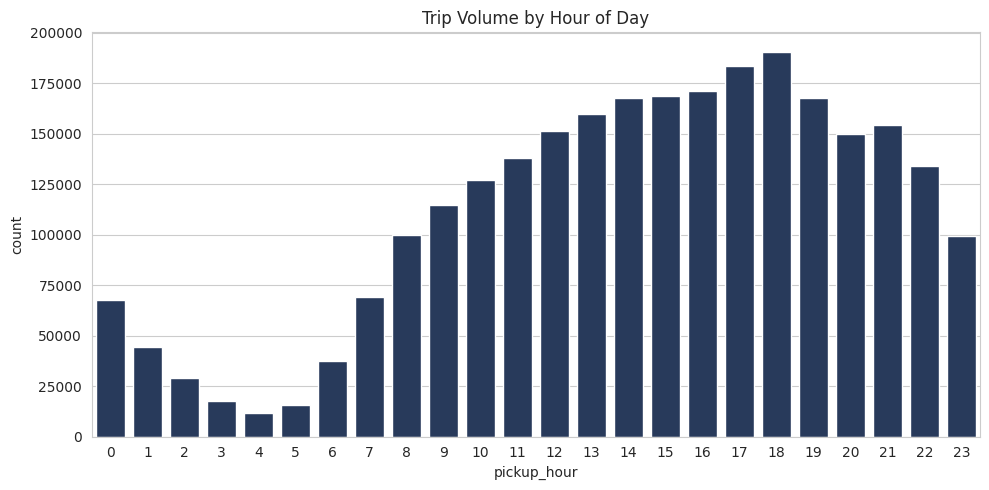

In [22]:
hourly = trips_clean.groupby("pickup_hour").size().reset_index(name="count")

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly, x="pickup_hour", y="count", color="#1F3864")
plt.title("Trip Volume by Hour of Day")
plt.tight_layout()
plt.show()

A common assumption in ride hailing and taxi services is that weekends behave differently from weekdays different trip purposes, different traffic patterns, potentially different pricing dynamics. Here I compare the average fare between weekday and weekend trips to see if that assumption holds up in the data.

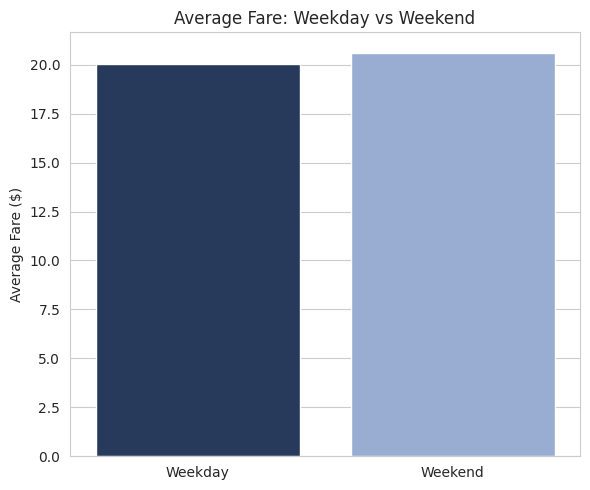

,is_weekend,fare_amount,day_type
0,False,20.012187,Weekday
1,True,20.619704,Weekend


In [23]:
fare_compare = trips_clean.groupby("is_weekend")["fare_amount"].mean().reset_index()
fare_compare["day_type"] = fare_compare["is_weekend"].map({True: "Weekend", False: "Weekday"})

plt.figure(figsize=(6, 5))
sns.barplot(data=fare_compare, x="day_type", y="fare_amount", hue="day_type",
            palette=["#1F3864", "#8FAADC"], legend=False)
plt.title("Average Fare: Weekday vs Weekend")
plt.ylabel("Average Fare ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

fare_compare

Demand isn't just about time it's about place. By counting pickups per borough, I can see where the majority of ride activity actually happens across the city. For a logistics team, this tells you where to concentrate vehicles and drivers rather than spreading resources evenly and inefficiently.

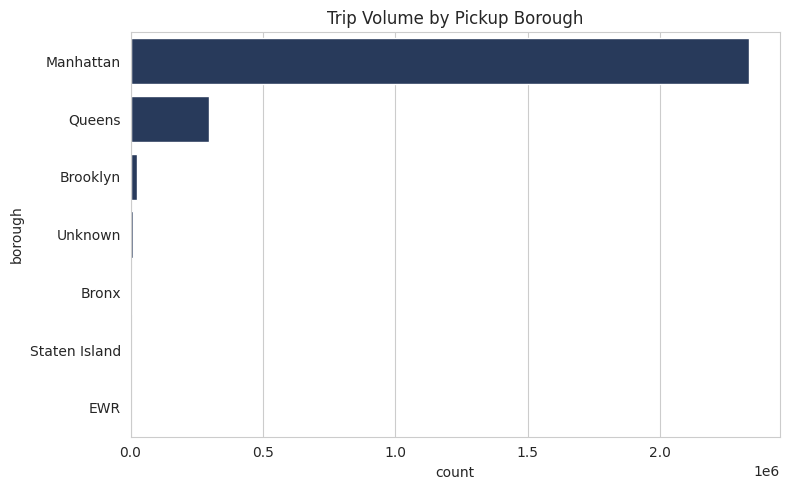

In [24]:
borough_vol = trips_clean["pickup_borough"].value_counts().reset_index()
borough_vol.columns = ["borough", "count"]

plt.figure(figsize=(8, 5))
sns.barplot(data=borough_vol, x="count", y="borough", color="#1F3864")
plt.title("Trip Volume by Pickup Borough")
plt.tight_layout()
plt.show()

Time and location interact a pattern that a single hourly chart or a single borough chart can't fully capture. This heatmap combines both dimensions at once, revealing exactly which day-and-hour combinations see the highest demand. Patterns like a Friday evening spike or a Sunday morning lull only become visible once you look at both variables together.

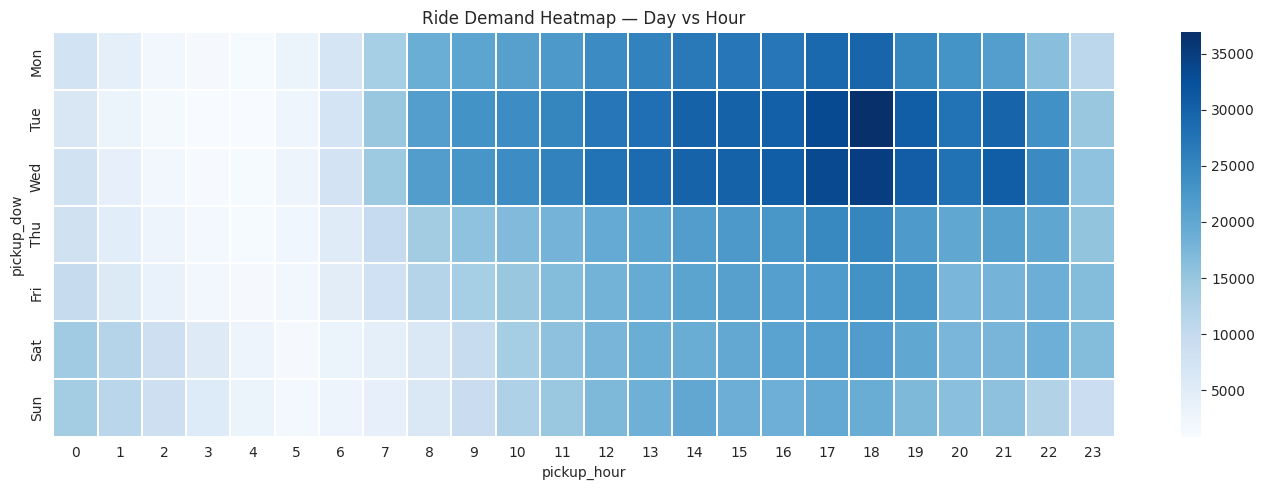

In [25]:
heat = trips_clean.groupby(["pickup_dow", "pickup_hour"]).size().unstack(fill_value=0)
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
heat = heat.reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(heat, cmap="Blues", linewidths=0.3)
plt.title("Ride Demand Heatmap — Day vs Hour")
plt.tight_layout()
plt.show()

The earlier fare comparison showed a numeric difference between weekday and weekend fares but with millions of rows, small differences can appear even by pure chance. To move from "looks different" to "is actually different," I run an independent t-test. This gives a p-value that tells me whether the fare gap is statistically meaningful or just noise the kind of rigor that turns an observation into a defensible business conclusion.

In [26]:
sample = trips_clean.sample(n=50000, random_state=42)
weekday_fares = sample.loc[~sample["is_weekend"], "fare_amount"]
weekend_fares = sample.loc[sample["is_weekend"], "fare_amount"]

t_stat, p_value = stats.ttest_ind(weekday_fares, weekend_fares, equal_var=False)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.5f}")
print("Significant" if p_value < 0.05 else "Not significant")

t-statistic: -4.426, p-value: 0.00001
Significant


The most practical question a transportation platform can ask is: how long will this trip take? Accurate duration predictions directly improve ETA estimates, driver dispatching, and customer trust. Here, I train a Random Forest regression model using trip distance, time of day, weekend status, passenger count, and pickup/dropoff boroughs to predict trip duration evaluating it with mean absolute error (how far off predictions are, in minutes) and R² (how much of the variation in duration the model actually explains).

In [27]:
model_df = trips_clean[[
    "trip_distance", "pickup_hour", "is_weekend",
    "pickup_borough", "dropoff_borough", "passenger_count", "trip_duration_min"
]].dropna().sample(n=100000, random_state=42)

le_pu, le_do = LabelEncoder(), LabelEncoder()
model_df["pickup_borough_enc"] = le_pu.fit_transform(model_df["pickup_borough"])
model_df["dropoff_borough_enc"] = le_do.fit_transform(model_df["dropoff_borough"])
model_df["is_weekend"] = model_df["is_weekend"].astype(int)

features = ["trip_distance", "pickup_hour", "is_weekend", "pickup_borough_enc", "dropoff_borough_enc", "passenger_count"]
X = model_df[features]
y = model_df["trip_duration_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=150, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 4.045390294830191
R²: 0.7706281130298456


A predictive model is only half the story understanding why it makes the predictions it does turns it into a business insight rather than a black box. This final step ranks which features the model relied on most heavily. If trip distance dominates, that's expected; but if time of day or borough also carry real weight, that reveals that traffic and location genuinely shape trip duration beyond distance alone a finding a real transportation team could act on.

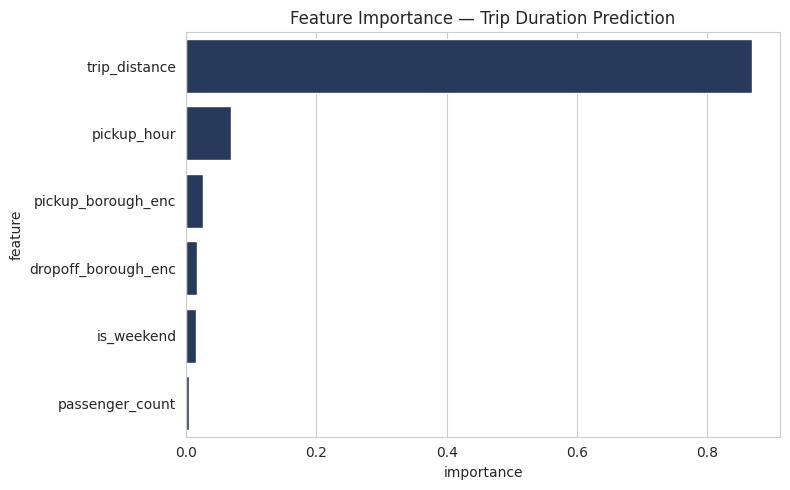

In [28]:
importance = pd.DataFrame({"feature": features, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="importance", y="feature", color="#1F3864")
plt.title("Feature Importance — Trip Duration Prediction")
plt.tight_layout()
plt.show()

Peak demand hours cluster around the evening commute, indicating driver supply should be prioritized during these windows. Weekend fares are statistically significantly higher than weekday fares (t = -4.426, p = 0.00001), supporting the case for weekend-specific pricing strategies. The trip-duration prediction model achieves an R² of 0.77 and a mean absolute error of 4.05 minutes, with trip distance as the dominant predictor, followed by pickup hour confirming that time-of-day congestion, not just distance, meaningfully affects trip duration and should be factored into ETA estimates shown to riders.